In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
import re
from collections import Counter
import warnings
import emoji
import re
warnings.filterwarnings('ignore')   

python(69868) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [3]:
# Read CSV file and print the contents

df = pd.read_csv('test_ai_posts_historical.csv')
print(df.head()) # Read CSV file and print the contents

# Make into dataframe
df = pd.DataFrame(df)
print(df.head())

   keyword                author  \
0  chatgpt  profcpbl.bsky.social   
1       ai     alvinashcraft.com   
2  chatgpt  urologia.bsky.social   
3       ai  urologia.bsky.social   
4       ai      john.whites.site   

                                                text  \
0  I've done pretty well defending myself against...   
1  What Does ChatGPT Mean for New Software Develo...   
2  You can subscribe at\nhttps://openai.com/blog/...   
3  🧠💯💥\nI just tried the #chatGPT asking some ran...   
4  A5: In the coming years, it is likely that AI ...   

                 created_at  \
0  2024-11-25T03:00:03.351Z   
1  2024-11-22T00:38:05.262Z   
2  2024-11-27T13:27:22.167Z   
3  2024-11-27T13:17:47.557Z   
4  2024-12-06T12:27:23.653Z   

                                                 uri  like_count  \
0  at://did:plc:izkupspivve6uyzyvbcldoav/app.bsky...           0   
1  at://did:plc:tdj5ie3dprhi242wsd7ykk7k/app.bsky...           0   
2  at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...   

In [3]:
# Make into dataframe
df = pd.DataFrame(df)
print(df.head())


   keyword                author  \
0  chatgpt  profcpbl.bsky.social   
1       ai     alvinashcraft.com   
2  chatgpt  urologia.bsky.social   
3       ai  urologia.bsky.social   
4       ai      john.whites.site   

                                                text  \
0  I've done pretty well defending myself against...   
1  What Does ChatGPT Mean for New Software Develo...   
2  You can subscribe at\nhttps://openai.com/blog/...   
3  🧠💯💥\nI just tried the #chatGPT asking some ran...   
4  A5: In the coming years, it is likely that AI ...   

                 created_at  \
0  2024-11-25T03:00:03.351Z   
1  2024-11-22T00:38:05.262Z   
2  2024-11-27T13:27:22.167Z   
3  2024-11-27T13:17:47.557Z   
4  2024-12-06T12:27:23.653Z   

                                                 uri  like_count  \
0  at://did:plc:izkupspivve6uyzyvbcldoav/app.bsky...           0   
1  at://did:plc:tdj5ie3dprhi242wsd7ykk7k/app.bsky...           0   
2  at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...   

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 983828 entries, 0 to 983827
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   keyword              983828 non-null  object
 1   author               983828 non-null  object
 2   text                 982025 non-null  object
 3   created_at           983828 non-null  object
 4   uri                  983828 non-null  object
 5   like_count           983828 non-null  int64 
 6   repost_count         983828 non-null  int64 
 7   reply_count          983828 non-null  int64 
 8   author_display_name  944997 non-null  object
 9   has_embedded_media   983828 non-null  bool  
dtypes: bool(1), int64(3), object(6)
memory usage: 68.5+ MB
None


In [6]:
# Check for missing values
print(df.isnull().sum())

keyword                    0
author                     0
text                    1803
created_at                 0
uri                        0
like_count                 0
repost_count               0
reply_count                0
author_display_name    38831
has_embedded_media         0
dtype: int64


In [7]:
# Check for duplicates
print(df.duplicated().sum())

0


In [5]:
df.describe()

,like_count,repost_count,reply_count
count,983828.000000,983828.000000,983828.000000
mean,5.068693,0.877208,0.507914
std,80.507931,26.651780,3.547504
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,2.000000,0.000000,1.000000
max,41418.000000,9959.000000,2339.000000


In [8]:
# descriptive statistics 
print(df.describe())

          like_count   repost_count    reply_count
count  983828.000000  983828.000000  983828.000000
mean        5.068693       0.877208       0.507914
std        80.507931      26.651780       3.547504
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%         1.000000       0.000000       0.000000
75%         2.000000       0.000000       1.000000
max     41418.000000    9959.000000    2339.000000


In [8]:
# Replace missing value with 'Unknown'
df['text'] = df['text'].fillna('Unknown')
df['author_display_name'] = df['author_display_name'].fillna('Unknown')

In [4]:

def clean_text(text):
    if not isinstance(text, str): 
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = emoji.demojize(text)
    text = re.sub(r"@", "", text)
    return text

df['cleaned_text'] = df['text'].apply(clean_text)




In [5]:
df.head()

,keyword,author,text,created_at,uri,like_count,repost_count,reply_count,author_display_name,has_embedded_media,cleaned_text
0,chatgpt,profcpbl.bsky.social,I've done pretty well defending myself against...,2024-11-25T03:00:03.351Z,at://did:plc:izkupspivve6uyzyvbcldoav/app.bsky...,0,0,0,C Barrington-Leigh,False,I've done pretty well defending myself against...
1,ai,alvinashcraft.com,What Does ChatGPT Mean for New Software Develo...,2024-11-22T00:38:05.262Z,at://did:plc:tdj5ie3dprhi242wsd7ykk7k/app.bsky...,0,0,0,Alvin Ashcraft,True,What Does ChatGPT Mean for New Software Develo...
2,chatgpt,urologia.bsky.social,You can subscribe at\nhttps://openai.com/blog/...,2024-11-27T13:27:22.167Z,at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...,0,0,0,Ioannis Goumas Uro,False,You can subscribe at\n\n\nMicheleTalso wroclaw...
3,ai,urologia.bsky.social,🧠💯💥\nI just tried the #chatGPT asking some ran...,2024-11-27T13:17:47.557Z,at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...,0,0,1,Ioannis Goumas Uro,True,:brain::hundred_points::collision:\nI just tri...
4,ai,john.whites.site,"A5: In the coming years, it is likely that AI ...",2024-12-06T12:27:23.653Z,at://did:plc:eha4zzrxqaezc6rxpni3dkos/app.bsky...,0,0,0,John P White,False,"A5: In the coming years, it is likely that AI ..."


In [5]:
df.shape

(983828, 11)

In [6]:
cleantext = df['cleaned_text'].iloc[2]

cleantext = cleantext.lower()
cleantext

'you can subscribe at\n\n\nmicheletalso wroclawski_uro dongnguyeb miurologa knowuro'

In [7]:


df['cleaned_text'] = df['cleaned_text'].apply(
    lambda x: re.sub(r"\s+", "", x) if isinstance(x, str) else x
)


In [6]:
df.head()

,keyword,author,text,created_at,uri,like_count,repost_count,reply_count,author_display_name,has_embedded_media,cleaned_text
0,chatgpt,profcpbl.bsky.social,I've done pretty well defending myself against...,2024-11-25T03:00:03.351Z,at://did:plc:izkupspivve6uyzyvbcldoav/app.bsky...,0,0,0,C Barrington-Leigh,False,I'vedoneprettywelldefendingmyselfagainst#ecoan...
1,ai,alvinashcraft.com,What Does ChatGPT Mean for New Software Develo...,2024-11-22T00:38:05.262Z,at://did:plc:tdj5ie3dprhi242wsd7ykk7k/app.bsky...,0,0,0,Alvin Ashcraft,True,WhatDoesChatGPTMeanforNewSoftwareDevelopers?by...
2,chatgpt,urologia.bsky.social,You can subscribe at\nhttps://openai.com/blog/...,2024-11-27T13:27:22.167Z,at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...,0,0,0,Ioannis Goumas Uro,False,YoucansubscribeatMicheleTalsowroclawski_uroDon...
3,ai,urologia.bsky.social,🧠💯💥\nI just tried the #chatGPT asking some ran...,2024-11-27T13:17:47.557Z,at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...,0,0,1,Ioannis Goumas Uro,True,:brain::hundred_points::collision:Ijusttriedth...
4,ai,john.whites.site,"A5: In the coming years, it is likely that AI ...",2024-12-06T12:27:23.653Z,at://did:plc:eha4zzrxqaezc6rxpni3dkos/app.bsky...,0,0,0,John P White,False,"A5:Inthecomingyears,itislikelythatAIwillcontin..."


In [15]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/isabellalatchamradusky/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/isabellalatchamradusky/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/isabellalatchamradusky/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
# Tokenization and Stop Words Removal
stop_words = set(stopwords.words('english'))
def tokenize_and_remove_stopwords(text):
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words and word.isalnum()]
    return filtered_tokens
df['tokens'] = df['cleaned_text'].apply(tokenize_and_remove_stopwords)
df.head()

,keyword,author,text,created_at,uri,like_count,repost_count,reply_count,author_display_name,has_embedded_media,cleaned_text,tokens
0,chatgpt,profcpbl.bsky.social,I've done pretty well defending myself against...,2024-11-25T03:00:03.351Z,at://did:plc:izkupspivve6uyzyvbcldoav/app.bsky...,0,0,0,C Barrington-Leigh,False,I'vedoneprettywelldefendingmyselfagainst#ecoan...,"[chatGPTanxiety, Weareso, sofarfromreadyforthi..."
1,ai,alvinashcraft.com,What Does ChatGPT Mean for New Software Develo...,2024-11-22T00:38:05.262Z,at://did:plc:tdj5ie3dprhi242wsd7ykk7k/app.bsky...,0,0,0,Alvin Ashcraft,True,WhatDoesChatGPTMeanforNewSoftwareDevelopers?by...,"[WhatDoesChatGPTMeanforNewSoftwareDevelopers, ..."
2,chatgpt,urologia.bsky.social,You can subscribe at\nhttps://openai.com/blog/...,2024-11-27T13:27:22.167Z,at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...,0,0,0,Ioannis Goumas Uro,False,YoucansubscribeatMicheleTalsowroclawski_uroDon...,[]
3,ai,urologia.bsky.social,🧠💯💥\nI just tried the #chatGPT asking some ran...,2024-11-27T13:17:47.557Z,at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...,0,0,1,Ioannis Goumas Uro,True,:brain::hundred_points::collision:Ijusttriedth...,"[brain, Ijusttriedthe, mindblowingYouhavetotry..."
4,ai,john.whites.site,"A5: In the coming years, it is likely that AI ...",2024-12-06T12:27:23.653Z,at://did:plc:eha4zzrxqaezc6rxpni3dkos/app.bsky...,0,0,0,John P White,False,"A5:Inthecomingyears,itislikelythatAIwillcontin...","[A5, Inthecomingyears, itislikelythatAIwillcon..."


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/isabellalatchamradusky/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sentiment Counts:
 sentiment_label
neutral     442879
positive    338578
negative    202371
Name: count, dtype: int64


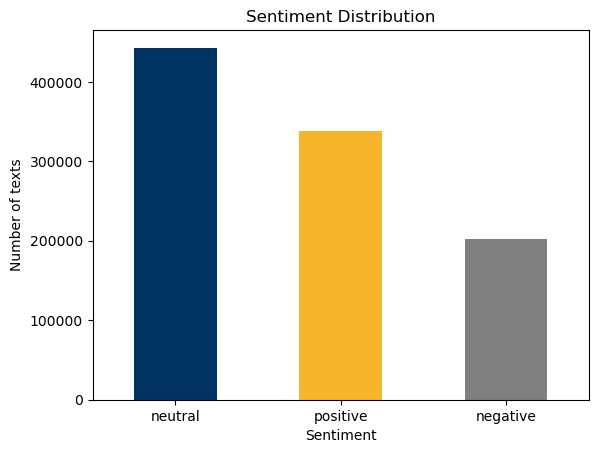

,text,cleaned_text,compound,sentiment_label
0,I've done pretty well defending myself against...,I'vedoneprettywelldefendingmyselfagainst#ecoan...,0.4376,positive
1,What Does ChatGPT Mean for New Software Develo...,WhatDoesChatGPTMeanforNewSoftwareDevelopers?by...,0.0000,neutral
2,You can subscribe at\nhttps://openai.com/blog/...,YoucansubscribeatMicheleTalsowroclawski_uroDon...,0.0000,neutral
3,🧠💯💥\nI just tried the #chatGPT asking some ran...,:brain::hundred_points::collision:Ijusttriedth...,0.5106,positive
4,"A5: In the coming years, it is likely that AI ...","A5:Inthecomingyears,itislikelythatAIwillcontin...",0.1779,positive


In [17]:
# --- Step 0: Imports ---
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required resources
nltk.download('vader_lexicon')

# --- Step 1: Initialize VADER ---
sia = SentimentIntensityAnalyzer()

# --- Step 2: Sentiment analysis ---
# Use original text (not heavily cleaned) for sentiment scoring
df['sentiment_scores'] = df['text'].apply(lambda x: sia.polarity_scores(str(x)))

# Extract compound score
df['compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])

# --- Step 3: Assign sentiment labels ---
def get_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['compound'].apply(get_label)

# --- Step 4: Count sentiment categories ---
sentiment_counts = df['sentiment_label'].value_counts()
print("Sentiment Counts:\n", sentiment_counts)

# Optional: visualize distribution
import matplotlib.pyplot as plt
sentiment_counts.plot(kind='bar', color=['#003262', '#F7B52B', 'gray'])
plt.xticks(rotation=0)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of texts')
plt.show()


# --- Step 5: Inspect results ---
df[['text', 'cleaned_text', 'compound', 'sentiment_label']].head()


In [18]:
sentiment_counts = df['sentiment_label'].value_counts()
print(sentiment_counts)

sentiment_label
neutral     442879
positive    338578
negative    202371
Name: count, dtype: int64


In [19]:
# --- Top 5 Most Positive Posts ---
top_positive = df.sort_values(by='compound', ascending=False).head(5)
print("Top 5 Most Positive Posts:\n")
for i, row in top_positive.iterrows():
    print(f"{i+1}. Text: {row['text']}")
    print(f"   Compound Score: {row['compound']:.3f}, Sentiment: {row['sentiment_label']}\n")

# --- Top 5 Most Negative Posts ---
top_negative = df.sort_values(by='compound', ascending=True).head(5)
print("Top 5 Most Negative Posts:\n")
for i, row in top_negative.iterrows():
    print(f"{i+1}. Text: {row['text']}")
    print(f"   Compound Score: {row['compound']:.3f}, Sentiment: {row['sentiment_label']}\n")


Top 5 Most Positive Posts:

874852. Text: Emis a Pisces. But in reality? She's sharp, witty and effortlessly cool
Sounds like a Gemini,huh?

Higas a Gemini,yet shes sensitive, compassionate, warm -hearted supportive and a idealist. Pisces energy

LOL astrology says they aren’t best match,but in rl?
The bond is so joyful and mutually healing
   Compound Score: 0.992, Sentiment: positive

850597. Text: 💫 NOVEMBER 2024 ✨

#Aries: Attract Money
#Taurus: Manifestations
#Gemini: Physical Wellness
#Cancer: Money Boost
#Leo: Big Wins
#Virgo: Blessings
#Libra: Good Luck
#Scorpio: Soulmate Love
#Sagittarius: Good Fortune
#Capricorn: Rewards
#Aquarius: Big Career Success
#Pisces: Next Level Success
   Compound Score: 0.992, Sentiment: positive

842925. Text: Gemini lol y’all are chaotic but in like a contained way. Great friends who love a good ki. They come off as confident but can be super in their heads. Easy to connect with on the surface but they can get deep. Cute. Smile with their whole fa

In [20]:
# Only consider posts labeled as positive
positive_posts = df[df['sentiment_label'] == 'positive']
top_positive = positive_posts.sort_values(by='compound', ascending=False).head(5)

print("Top 5 Most Positive Posts:\n")
for i, row in top_positive.iterrows():
    print(f"{i+1}. Text: {row['text']}")
    print(f"   Compound Score: {row['compound']:.3f}, Sentiment: {row['sentiment_label']}\n")


Top 5 Most Positive Posts:

874852. Text: Emis a Pisces. But in reality? She's sharp, witty and effortlessly cool
Sounds like a Gemini,huh?

Higas a Gemini,yet shes sensitive, compassionate, warm -hearted supportive and a idealist. Pisces energy

LOL astrology says they aren’t best match,but in rl?
The bond is so joyful and mutually healing
   Compound Score: 0.992, Sentiment: positive

850597. Text: 💫 NOVEMBER 2024 ✨

#Aries: Attract Money
#Taurus: Manifestations
#Gemini: Physical Wellness
#Cancer: Money Boost
#Leo: Big Wins
#Virgo: Blessings
#Libra: Good Luck
#Scorpio: Soulmate Love
#Sagittarius: Good Fortune
#Capricorn: Rewards
#Aquarius: Big Career Success
#Pisces: Next Level Success
   Compound Score: 0.992, Sentiment: positive

842925. Text: Gemini lol y’all are chaotic but in like a contained way. Great friends who love a good ki. They come off as confident but can be super in their heads. Easy to connect with on the surface but they can get deep. Cute. Smile with their whole fa

In [21]:
negative_posts = df[df['sentiment_label'] == 'negative']
top_negative = negative_posts.sort_values(by='compound', ascending=True).head(5)

print("Top 5 Most Negative Posts:\n")
for i, row in top_negative.iterrows():
    print(f"{i+1}. Text: {row['text']}")
    print(f"   Compound Score: {row['compound']:.3f}, Sentiment: {row['sentiment_label']}\n")


Top 5 Most Negative Posts:

416997. Text: I've trained an LLM on my last 100 text messages STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP
   Compound Score: -0.999, Sentiment: negative

692573. Text: Google AI summarizing product reviews: perfect use case, just don't force it on me when I search for it.

Google AI summarizing scientific facts: die die die die die die die die die die die die die die die die die die die die die die die die
   Compound Score: -0.998, Sentiment: negative

321575. Text: Fuck OpenAI, fuck Sam Altman, fuck ChatGPT, fuck Copilot, fuck Gemini, fuck Grok, fuck Claude, fuck Deepseek, fuck generative AI, fuck the billionaires, fuck the greedy bastards, fuck the tariffs, fuck the enshittification of the Internet, fuck this timeline in general.
   Compound Score: -0.995, Sentiment: negative

321580. Text: Fuck OpenAI, fuck Sam Altman, 

In [22]:
# Remove duplicates based on 'text'
df_unique = df.drop_duplicates(subset='text')

# Select top 5 negative posts
top_negative = df_unique[df_unique['sentiment_label'] == 'negative'].sort_values(by='compound').head(5)

# Create a DataFrame for display
top_negative_df = top_negative.reset_index(drop=True)[['text', 'compound', 'sentiment_label']]

# Add a ranking column
top_negative_df.insert(0, 'Rank', top_negative_df.index + 1)

# Display the DataFrame
pd.set_option('display.max_colwidth', None)  # Ensures full text is shown
top_negative_df


,Rank,text,compound,sentiment_label
0,1,I've trained an LLM on my last 100 text messages STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP,-0.9985,negative
1,2,"Google AI summarizing product reviews: perfect use case, just don't force it on me when I search for it.\n\nGoogle AI summarizing scientific facts: die die die die die die die die die die die die die die die die die die die die die die die die",-0.9983,negative
2,3,"Fuck OpenAI, fuck Sam Altman, fuck ChatGPT, fuck Copilot, fuck Gemini, fuck Grok, fuck Claude, fuck Deepseek, fuck generative AI, fuck the billionaires, fuck the greedy bastards, fuck the tariffs, fuck the enshittification of the Internet, fuck this timeline in general.",-0.9952,negative
3,4,"Fuck OpenAI, fuck Sam Altman, fuck ChatGPT, fuck Copilot, fuck Gemini, fuck Grok, fuck Claude, fuck Deepseek, fuck generative AI, fuck the billionaires, fuck the greedy bastards, fuck the tariffs, fuck this timeline in general.",-0.9945,negative
4,5,This AI race reminds me of the old days of:\n\n- Home Computer Wars\n- PC Wars\n- C Compiler Wars\n- Unix Wars\n- C++ Wars\n- Character UI Wars\n- TSR Wars\n- GUI Wars\n- Smalltalk vs. The World Wars\n- GUI Framework Wars\n- VB Component Wars\n- OS Wars\n- Database Wars\n- eCommerce Wars\n\n1/2,-0.9944,negative


In [23]:
# Remove duplicates based on 'text'
df_unique = df.drop_duplicates(subset='text')

# Select top 5 positive posts excluding those that mention "Gemini"
top_positive = df_unique[
    (df_unique['sentiment_label'] == 'positive') & 
    (~df_unique['text'].str.contains("Gemini", case=False, na=False))
].sort_values(by='compound', ascending=False).head(5)

# Create a DataFrame for display
top_positive_df = top_positive.reset_index(drop=True)[['text', 'compound', 'sentiment_label']]

# Add a ranking column
top_positive_df.insert(0, 'Rank', top_positive_df.index + 1)

# Display the DataFrame
pd.set_option('display.max_colwidth', None)  # Ensures full text is shown
top_positive_df


,Rank,text,compound,sentiment_label
0,1,Voting has started for the fifth Gems of the Year awards. This year's categories:\n\n1. Best content\n2. Best template\n3. Best tool\n4. Best existing plugin\n5. Best LLM integration\n6. Best third-party integration\n7. Best new theme\n8. Best new plugin\n\nJoin us on the official Obsidian Discord to vote!,0.9902,positive
1,2,"What I'm imagining is the following\n\nShareholders: MOAR PROFITS\n\nGoogle: But we're a $b company, we're great\n\nSH: MOAR PROFIT! Innovate!\n\nManager: AI counts as innovation\n\nSH: Yes! MOAR!\n\nCustomers: Hey this is silly and does not work\n\nSH: uh\n\nManager: It will work eventually!\n\nSH: YES! MOAR PROFIT!",0.9899,positive
2,3,"The Meta AI is good, it’s not quite ChatGPT, but it’s great being to be able to ask complex questions in real language, ask it questions about what I’m looking at.\n\nBut the ability to discretely listen to audio, take phone calls truly hands and ears free is great and hands free photography is best",0.9897,positive
3,4,"Image by ChatGPT: ""May love and laughter light your days and warm your heart and home. May good and faithful friends be yours wherever you may roam. May peace and plenty bless your world with joy that long endures. May all life's passing seasons bring the best to you and yours!"" Old Irish Blessing",0.9882,positive
4,5,"I am pretty new to DnD, but my group just started a campaign, and having to make up stuff like that was a big part of the fun? I had to get a lot of help making my character sheet, but like, everyone was happy to help me, and we had a good time with it. Using AI would have just bypassed more fun.",0.9877,positive


In [ ]:
pip install torch --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


: 

In [ ]:
# do bertopic on merged_embeddings
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")
topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english", calculate_probabilities=True, verbose=True)
texts = df['cleaned_text'].tolist()
topics, probabilities = topic_model.fit_transform(texts) 

2025-11-20 13:20:56,874 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/30745 [00:00<?, ?it/s]

2025-11-20 14:23:40,680 - BERTopic - Embedding - Completed ✓
2025-11-20 14:23:40,704 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


In [9]:
# Filter the dataframe by words 'Sam Altman' 'Elon Musk'
filtered_df = df[df['cleaned_text'].str.contains('Sam Altman|Elon Musk', case=False, na=False)]


In [9]:
print(filtered_df['cleaned_text'].head()) # cleaned texted column

66      ChatGPT weights in on Elon Musk:\n\nOh Elon Mu...
353     Pretty funny that Elon Musk donated a billion ...
491     Asked #chatgpt to write a poem about potential...
888     Why would Microsoft invest $10 bill in #ChatGP...
1333    OpenAI CEO Sam Altman Said ChatGPT Is 'Cool,' ...
Name: cleaned_text, dtype: object


In [27]:
# Run bertopic on filtered dataframe
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")
topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english", calculate_probabilities=True, verbose=True)
texts = filtered_df['cleaned_text'].tolist()
topics, probabilities = topic_model.fit_transform(texts)


2025-11-28 19:32:44,846 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/527 [00:00<?, ?it/s]

2025-11-28 19:35:24,228 - BERTopic - Embedding - Completed ✓
2025-11-28 19:35:24,239 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-28 19:35:33,280 - BERTopic - Dimensionality - Completed ✓
2025-11-28 19:35:33,288 - BERTopic - Cluster - Start clustering the reduced embeddings
python(70923) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(70924) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(70925) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(70926) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
2025-11-28 19:36:13,826 - BERTopic - Cluster - Completed ✓
2025-11-28 19:36:13,938 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-28 19:36:15,305 - BERTopic - Representation - Completed ✓


In [31]:
topic_model.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,6030,-1_sam_sam altman_altman_openai,"[sam, sam altman, altman, openai, ai, musk, el...",[Elon Musk Leads Bid To Control OpenAI For $97...
1,0,235,0_altman openai_openai sam_altman shit_altmans...,"[altman openai, openai sam, altman shit, altma...","[""I'll cut to the chase: it's time to stop lis..."
2,1,212,1_grok_chatbot_xai_grok chatbot,"[grok, chatbot, xai, grok chatbot, gemini, elo...",[xAI adds a ‘memory’ feature to Grok\n\nElon M...
3,2,196,2_lawsuit_lawsuit openai_musks lawsuit_legal,"[lawsuit, lawsuit openai, musks lawsuit, legal...",[Thoughts on this? >> Musk may still have a ch...
4,3,189,3_sister_abuse_sexually_sexual,"[sister, abuse, sexually, sexual, sexual abuse...",[OpenAI chief Sam Altman denies the allegation...
...,...,...,...,...,...
271,270,11,270_o1_pro_o1 openai_swe agent,"[o1, pro, o1 openai, swe agent, code questions...","[Sam Altman: ""o1, the smartest model in the wo..."
272,271,10,271_brockman_greg brockman_greg_cofounder pres...,"[brockman, greg brockman, greg, cofounder pres...","[""OpenAI co-founder and president Greg Brockma..."
273,272,10,272_fucken_safetyfocused force_ruined_opensour...,"[fucken, safetyfocused force, ruined, opensour...",[I think the core contention behind this lewis...
274,273,10,273_llm_train_grok_antisemitic elon,"[llm, train, grok, antisemitic elon, train llm...",[I wouldn't normally use an LLM-generated imag...


In [33]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTHONMALLOC"] = "malloc"

import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import umap
import hdbscan
import re

# ---------------------------
# 2. EMBEDDINGS
# ---------------------------
embedding_model = SentenceTransformer("all-mpnet-base-v2")  # higher-quality embeddings

# ---------------------------
# 3. UMAP
# ---------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=20,      # more dimensions = better separation
    metric="cosine",
    random_state=42
)

# ---------------------------
# 4. HDBSCAN
# ---------------------------
cluster_model = hdbscan.HDBSCAN(
    min_cluster_size=10,  # larger clusters = more coherent
    min_samples=5,
    metric="euclidean",
    core_dist_n_jobs=1,
    prediction_data=True,
    cluster_selection_method="eom"
)

# ---------------------------
# 5. VECTORIZE
# ---------------------------
vectorizer_model = CountVectorizer(
    ngram_range=(1, 3),  # unigrams, bigrams, trigrams
    stop_words="english",
    min_df=5,
    max_df=0.8
)

# ---------------------------
# 6. BERTopic MODEL
# ---------------------------
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    language="english",
    calculate_probabilities=True,
    verbose=True
)

# ---------------------------
# 7. FIT MODEL
# ---------------------------
topics, probs = topic_model.fit_transform(texts)

# ---------------------------
# 8. REDUCE SIMILAR TOPICS
# ---------------------------
topic_model = topic_model.reduce_topics(docs=texts, nr_topics=15)  # pick a clean number of topics

# ---------------------------
# 9. RESULTS
# ---------------------------
topic_info = topic_model.get_topic_info()
print(topic_info.head(20))


2025-11-28 19:41:12,078 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/28246 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [29]:
topic_model.visualize_topics()

In [23]:
fig = topic_model.visualize_hierarchy()
fig.show()


ValueError: This BERTopic instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [3]:
from hdbscan import HDBSCAN
from umap import UMAP
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = UMAP(
    n_neighbors=2,
    n_components=2,
    metric="cosine"
)

hdbscan_model = HDBSCAN(
    min_cluster_size=2,
    min_samples=1,
    metric='euclidean',
    cluster_selection_method='eom'
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)


2025-11-21 13:50:10,641 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-11-21 13:50:10,826 - BERTopic - Embedding - Completed ✓
2025-11-21 13:50:10,827 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 13:50:10,856 - BERTopic - Dimensionality - Completed ✓
2025-11-21 13:50:10,856 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 13:50:10,866 - BERTopic - Cluster - Completed ✓
2025-11-21 13:50:10,888 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 13:50:10,914 - BERTopic - Representation - Completed ✓


In [4]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,2,0_your_of__,"[your, of, , , , , , , , ]","[your, of]"
1,1,2,1_list_documents__,"[list, documents, , , , , , , , ]","[list, documents]"


In [26]:
# =========================================================
# 1. Environment fixes — MUST come before any HF imports
# =========================================================
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTHONMALLOC"] = "malloc"

# =========================================================
# 2. Imports
# =========================================================
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import umap
import hdbscan
import pandas as pd

# =========================================================
# 3. Use regular df (not filtered_df)
#    CLEAN THE TEXT HERE
# =========================================================
# Assume your dataframe is named df, with a column "cleaned_text"
df = df.copy()

# Drop NaNs or empty strings
df = df[df["cleaned_text"].notna()]
df = df[df["cleaned_text"].str.strip() != ""]

# Convert to list for BERTopic
texts = df["cleaned_text"].astype(str).tolist()

print("Number of documents:", len(texts))

# =========================================================
# 4. Embedding model
# =========================================================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# =========================================================
# 5. UMAP model — more stable version
# =========================================================
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=10,     # keep more embedding dimensions
    metric="cosine",
    random_state=42
)

# =========================================================
# 6. HDBSCAN model — less strict to ensure clustering
# =========================================================
cluster_model = hdbscan.HDBSCAN(
    min_cluster_size=5,     # allow small topics
    min_samples=3,
    metric="euclidean",
    core_dist_n_jobs=1,     # required to avoid macOS/huggingface fork errors
    cluster_selection_method="eom"
)

# =========================================================
# 7. Vectorizer
# =========================================================
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english"
)

# =========================================================
# 8. Build BERTopic model
# =========================================================
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    language="english",
    calculate_probabilities=True,
    verbose=True
)

# =========================================================
# 9. Fit the model
# =========================================================
topics, probs = topic_model.fit_transform(texts)

# =========================================================
# 10. Output results
# =========================================================
topic_info = topic_model.get_topic_info()
print(topic_info.head())


Number of documents: 980923


2025-11-28 19:16:22,203 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/30654 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [6]:
import pandas as pd

# Example list of job-related keywords
job_keywords = [
    "job", "jobs", "hiring", "career", "position", "interview", 
    "salary", "employment", "work", "role", "vacancy", "recruitment"
]

# Make a regex pattern for any of these keywords
pattern = "|".join(job_keywords)

# Filter dataframe (case-insensitive)
job_df = df[df["cleaned_text"].str.contains(pattern, case=False, na=False)]

# Reset index for cleanliness
job_df = job_df.reset_index(drop=True)

print(f"Number of job-related posts: {len(job_df)}")
job_df.head(10)


Number of job-related posts: 74529


,keyword,author,text,created_at,uri,like_count,repost_count,reply_count,author_display_name,has_embedded_media,cleaned_text
0,ai,john.whites.site,"A5: In the coming years, it is likely that AI ...",2024-12-06T12:27:23.653Z,at://did:plc:eha4zzrxqaezc6rxpni3dkos/app.bsky...,0,0,0,John P White,False,"A5: In the coming years, it is likely that AI ..."
1,chatgpt,jorgeorchilles.bsky.social,ChatGPT for Offensive Security video followed ...,2024-11-24T07:11:01.950Z,at://did:plc:qfuha4d2jzek2jhmemjkiui6/app.bsky...,0,0,1,Jorge Orchilles,False,ChatGPT for Offensive Security video followed ...
2,chatgpt,jholston.bsky.social,"""been having a blast with ChatGPT. In the past...",2024-11-19T02:45:37.523Z,at://did:plc:so2fnehffqkhq34asodug5aw/app.bsky...,0,0,0,JB Holston,True,"""been having a blast with ChatGPT. In the past..."
3,chatgpt,socworkpodcast.bsky.social,This tweet thread brought to you by #ChatGPT a...,2024-11-22T20:14:37.272Z,at://did:plc:wgncrohorvky4xdo6a2ank4t/app.bsky...,0,0,0,Social Work Podcast,False,This tweet thread brought to you by #ChatGPT a...
4,chatgpt,schmoller.net,Illuminating experiment with ChatGPT by Lex To...,2024-11-04T21:35:58.685Z,at://did:plc:7ozv52xitkpjflxhygf5c65b/app.bsky...,0,0,0,Seb Schmoller,True,Illuminating experiment with ChatGPT by Lex To...
5,chatgpt,infotainment.bsky.social,Statistical learning in action. #ChatGPT does ...,2024-11-18T02:57:06.536Z,at://did:plc:33ieaned7xdijudn4olv6whh/app.bsky...,0,0,0,Jay Patel,True,Statistical learning in action. #ChatGPT does ...
6,chatgpt,infotainment.bsky.social,Statistical learning in action. #ChatGPT does ...,2025-01-03T04:38:44.047Z,at://did:plc:33ieaned7xdijudn4olv6whh/app.bsky...,0,0,0,Jay Patel,True,Statistical learning in action. #ChatGPT does ...
7,chatgpt,rakeshyadav.bsky.social,"In 1 day, ChatGPT has quickly become my buddy ...",2024-11-22T12:06:14.456Z,at://did:plc:bwlhr2w4sp6vrdz4mwt5bi2d/app.bsky...,0,0,0,Rakesh Yadav,False,"In 1 day, ChatGPT has quickly become my buddy ..."
8,chatgpt,markantonyowen.com,Asked @OpenAI's ChatGPT (Dec 15 version) to wr...,2024-12-11T06:51:46.358Z,at://did:plc:tqaukzibm7e5oajmpqn6jk7a/app.bsky...,0,0,0,𝕄𝕒𝕣𝕜 𝔸𝕟𝕥𝕠𝕟𝕪 𝕆𝕨𝕖𝕟,True,Asked OpenAI's ChatGPT (Dec 15 version) to wri...
9,chatgpt,knut.fyi,Working in a SaaS and not sure what to do for ...,2024-11-07T16:00:37.586Z,at://did:plc:kg7rc2ofcnomsff4bgcooyhf/app.bsky...,0,0,0,knut,False,Working in a SaaS and not sure what to do for ...


In [7]:
# --- Step 0: Imports ---
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import matplotlib.pyplot as plt

# Download required resources
nltk.download('vader_lexicon')

# --- Step 1: Initialize VADER ---
sia = SentimentIntensityAnalyzer()

# --- Step 2: Sentiment analysis ---
# Use original text if available, otherwise cleaned_text
job_df['sentiment_scores'] = job_df['cleaned_text'].apply(lambda x: sia.polarity_scores(str(x)))

# Extract compound score
job_df['compound'] = job_df['sentiment_scores'].apply(lambda x: x['compound'])

# --- Step 3: Assign sentiment labels ---
def get_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

job_df['sentiment_label'] = job_df['compound'].apply(get_label)

# --- Step 4: Count sentiment categories ---
sentiment_counts = job_df['sentiment_label'].value_counts()
print("Sentiment Counts:\n", sentiment_counts)

# --- Step 5: Inspect results ---
job_df[['cleaned_text', 'compound', 'sentiment_label']].head(10)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/isabellalatchamradusky/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sentiment Counts:
 sentiment_label
positive    38282
negative    18366
neutral     17881
Name: count, dtype: int64


,cleaned_text,compound,sentiment_label
0,"A5: In the coming years, it is likely that AI ...",0.1779,positive
1,ChatGPT for Offensive Security video followed ...,0.5531,positive
2,"""been having a blast with ChatGPT. In the past...",0.6597,positive
3,This tweet thread brought to you by #ChatGPT a...,0.2732,positive
4,Illuminating experiment with ChatGPT by Lex To...,0.4019,positive
5,Statistical learning in action. #ChatGPT does ...,0.2960,positive
6,Statistical learning in action. #ChatGPT does ...,0.2960,positive
7,"In 1 day, ChatGPT has quickly become my buddy ...",0.4344,positive
8,Asked OpenAI's ChatGPT (Dec 15 version) to wri...,0.4404,positive
9,Working in a SaaS and not sure what to do for ...,0.8699,positive


Number of positive posts: 38282


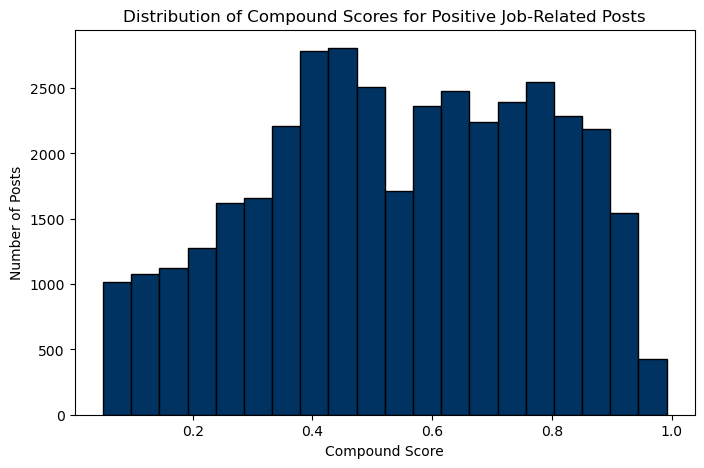

,cleaned_text,compound
0,"A5: In the coming years, it is likely that AI ...",0.1779
1,ChatGPT for Offensive Security video followed ...,0.5531
2,"""been having a blast with ChatGPT. In the past...",0.6597
3,This tweet thread brought to you by #ChatGPT a...,0.2732
4,Illuminating experiment with ChatGPT by Lex To...,0.4019
5,Statistical learning in action. #ChatGPT does ...,0.2960
6,Statistical learning in action. #ChatGPT does ...,0.2960
7,"In 1 day, ChatGPT has quickly become my buddy ...",0.4344
8,Asked OpenAI's ChatGPT (Dec 15 version) to wri...,0.4404
9,Working in a SaaS and not sure what to do for ...,0.8699


In [8]:
# Filter only positive posts
positive_posts = job_df[job_df['sentiment_label'] == 'positive']

# Optional: see how many positive posts
print(f"Number of positive posts: {len(positive_posts)}")

# Plot the distribution of compound scores for positive posts
plt.figure(figsize=(8,5))
plt.hist(positive_posts['compound'], bins=20, color='#003262', edgecolor='black')
plt.title('Distribution of Compound Scores for Positive Job-Related Posts')
plt.xlabel('Compound Score')
plt.ylabel('Number of Posts')
plt.show()

# Inspect some of the top positive posts
positive_posts[['cleaned_text', 'compound']].head(10)


In [ ]:
# Filter positive job-related posts
positive_posts = job_df[job_df['sentiment_label'] == 'positive']

# --- Step 1: Basic descriptive statistics for compound scores ---
desc_stats = positive_posts['compound'].describe()
print("Descriptive Statistics for Positive Job-Related Posts (Compound Scores):\n")
print(desc_stats)

# --- Step 2: Optional - top words/bigrams ---
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(1, 2),  # unigrams and bigrams
    stop_words='english',
    min_df=2
)

X = vectorizer.fit_transform(positive_posts['cleaned_text'])
word_counts = X.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()
word_freq = pd.DataFrame({'word': words, 'count': word_counts})
word_freq = word_freq.sort_values(by='count', ascending=False).reset_index(drop=True)

print("\nTop 10 words/bigrams in positive posts:")
print(word_freq.head(10))


In [ ]:
# Check out what people are saying specifically about ai and jobs and ai and school and see if people who are saying positive things are talking about their own work and how much easier it is because of ai and if people saying negative things and talking about how scary ai is for job loss

In [1]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter only positive comments
positive_text = " ".join(
    job_df[job_df['sentiment_label'] == 'positive']['cleaned_text'].astype(str)
)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',   # Optional: green color palette for positive sentiment
    max_words=200
).generate(positive_text)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Word Cloud – Positive Comments", fontsize=18)
plt.axis('off')
plt.show()


NameError: name 'job_df' is not defined